# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

#### Primary Goal
Understand what factors make used cars more or less expensive to provide actionable recommendations to a used car dealership for optimizing inventory, pricing strategy, and marketing efforts.

#### Secondary Goals
- Identify key value drivers that influence car prices
- Enable data-driven pricing strategies for competitive advantage
- Optimize inventory acquisition decisions
- Improve profitability through better pricing intelligence
- Develop customer targeting strategies based on value preferences

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder, QuantileTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
vehicles_df = pd.read_csv('vehicles.csv')

In [3]:
vehicles_df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
vehicles_df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [6]:
# Identify Missing Values

missing_percentages = vehicles_df.isnull().sum() / len(vehicles_df) * 100
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print("Percentage of missing values per column (descending order):\n")
print(missing_percentages)

Percentage of missing values per column (descending order):

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
dtype: float64


### Strategy for Handling Missing Values

Based on the percentage of missing values, here's a proposed strategy for each column:

1.  **Columns with High Missingness (> 30%):**
    *   `size` (71.77% missing): This column has a very high percentage of missing values. Given its high missingness and potentially complex relationship with price, it's best to **drop this column** entirely. Trying to impute it would introduce too much noise or bias.
    *   `cylinders` (41.62% missing): This is a categorical feature. While it has significant missingness, `cylinders` can be an important factor for car performance and value. We will **impute with a new category 'unknown'** to retain rows and acknowledge the missing information.
    *   `condition` (40.79% missing): This is a categorical feature. Similar to `cylinders`, `condition` is vital for pricing. We will **impute with the mode** or a new category 'unknown'. For now, we will use 'unknown'.
    *   `VIN` (37.73% missing): VINs are unique identifiers and are not useful for direct price prediction or imputation in a meaningful way. We will **drop this column**.
    *   `drive` (30.59% missing): This is a categorical feature important for car characteristics. We will **impute with the mode** or a new category 'unknown'. For now, we will use 'unknown'.
    *   `paint_color` (30.50% missing): This is a categorical feature. While color can influence preference, its direct impact on price might be less significant than other features. We will **impute with the mode** or a new category 'unknown'. For now, we will use 'unknown'.

2.  **Columns with Moderate Missingness (20-30%):**
    *   `type` (21.75% missing): This is a categorical feature (`car type`). This can be an important predictor. We will **impute with the mode** or a new category 'unknown'. For now, we will use 'unknown'.

3.  **Columns with Low Missingness (< 5%):**
    *   `manufacturer` (4.13% missing): This is a categorical feature crucial for car brand recognition and value. We will **impute with the mode**.
    *   `title_status` (1.93% missing): This is a categorical feature. It's important to know the title status. We will **impute with the mode**.
    *   `model` (1.24% missing): This is a categorical feature and is highly influential on car price. We will **impute with the mode**.
    *   `odometer` (1.03% missing): This is a numerical feature (mileage). We will **impute with the median** to minimize the effect of potential outliers.
    *   `fuel` (0.71% missing): This is a categorical feature. We will **impute with the mode**.
    *   `transmission` (0.60% missing): This is a categorical feature. We will **impute with the mode**.
    *   `year` (0.28% missing): This is a numerical feature crucial for car age. We will **impute with the median** to minimize the effect of potential outliers.

**Summary of Actions:**
*   **Drop Columns:** `size`, `VIN`
*   **Impute with 'unknown' category (for high/moderate categorical missingness):** `cylinders`, `condition`, `drive`, `paint_color`, `type`
*   **Impute with Mode (for low categorical missingness):** `manufacturer`, `title_status`, `model`, `fuel`, `transmission`
*   **Impute with Median (for low numerical missingness):** `odometer`, `year`

In [7]:
print("Original shape of DataFrame:", vehicles_df.shape)

# Drop columns with high missingness
columns_to_drop = ['size', 'VIN']
vehicles_df = vehicles_df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

# Impute categorical columns with 'unknown' for high/moderate missingness
unknown_impute_cols = ['cylinders', 'condition', 'drive', 'paint_color', 'type']
for col in unknown_impute_cols:
    vehicles_df[col] = vehicles_df[col].fillna('unknown')
print(f"Imputed with 'unknown': {unknown_impute_cols}")

# Impute categorical columns with mode for low missingness
mode_impute_cols = ['manufacturer', 'title_status', 'model', 'fuel', 'transmission']
for col in mode_impute_cols:
    # Calculate mode only for non-null values to avoid issues with 'unknown' if it already exists
    mode_val = vehicles_df[col].mode()[0]
    vehicles_df[col] = vehicles_df[col].fillna(mode_val)
print(f"Imputed with mode: {mode_impute_cols}")

# Impute numerical columns with median for low missingness
median_impute_cols = ['odometer', 'year']
for col in median_impute_cols:
    median_val = vehicles_df[col].median()
    vehicles_df[col] = vehicles_df[col].fillna(median_val)
print(f"Imputed with median: {median_impute_cols}")

# Verify that there are no more missing values in the affected columns
remaining_missing = vehicles_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("\nAll specified missing values handled successfully.")
else:
    print("\nRemaining missing values after handling:")
    print(remaining_missing)

print("\nNew shape of DataFrame:", vehicles_df.shape)
print("\nVerify first few rows after imputation:")
print(vehicles_df.head())

Original shape of DataFrame: (426880, 18)
Dropped columns: ['size', 'VIN']
Imputed with 'unknown': ['cylinders', 'condition', 'drive', 'paint_color', 'type']
Imputed with mode: ['manufacturer', 'title_status', 'model', 'fuel', 'transmission']
Imputed with median: ['odometer', 'year']

All specified missing values handled successfully.

New shape of DataFrame: (426880, 16)

Verify first few rows after imputation:
           id                  region  price    year manufacturer  model  \
0  7222695916                prescott   6000  2013.0         ford  f-150   
1  7218891961            fayetteville  11900  2013.0         ford  f-150   
2  7221797935            florida keys  21000  2013.0         ford  f-150   
3  7222270760  worcester / central MA   1500  2013.0         ford  f-150   
4  7210384030              greensboro   4900  2013.0         ford  f-150   

  condition cylinders fuel  odometer title_status transmission    drive  \
0   unknown   unknown  gas   85548.0        clean   

In [8]:
### Remove Duplicates
print(f"Initial shape of DataFrame: {vehicles_df.shape}")

duplicate_rows = vehicles_df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

vehicles_df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after removing duplicates: {vehicles_df.shape}")

Initial shape of DataFrame: (426880, 16)
Number of duplicate rows found: 0
Shape of DataFrame after removing duplicates: (426880, 16)


## Correct Data Types

In [9]:
vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          426880 non-null  float64
 4   manufacturer  426880 non-null  object 
 5   model         426880 non-null  object 
 6   condition     426880 non-null  object 
 7   cylinders     426880 non-null  object 
 8   fuel          426880 non-null  object 
 9   odometer      426880 non-null  float64
 10  title_status  426880 non-null  object 
 11  transmission  426880 non-null  object 
 12  drive         426880 non-null  object 
 13  type          426880 non-null  object 
 14  paint_color   426880 non-null  object 
 15  state         426880 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 52.1+ MB


In [10]:
print("Converting 'year' and 'odometer' to integer types...")
vehicles_df['year'] = vehicles_df['year'].astype(int)
vehicles_df['odometer'] = vehicles_df['odometer'].astype(int)


Converting 'year' and 'odometer' to integer types...


## Identifying and Addressing Outliers


--- Analyzing column: price ---


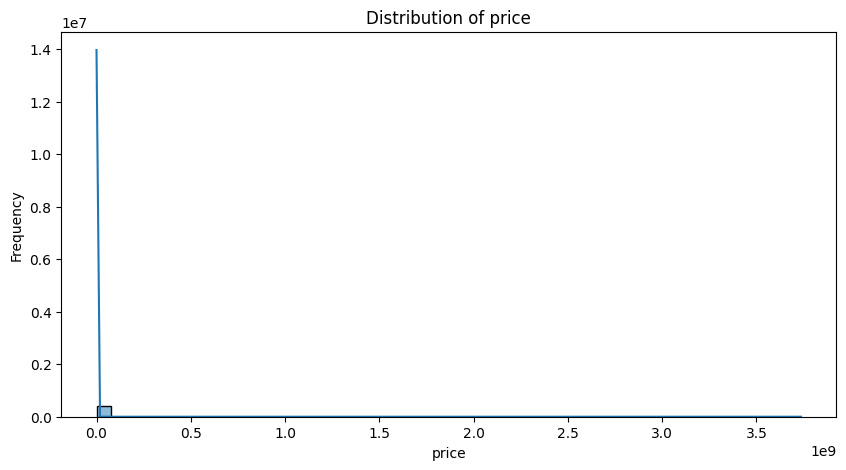

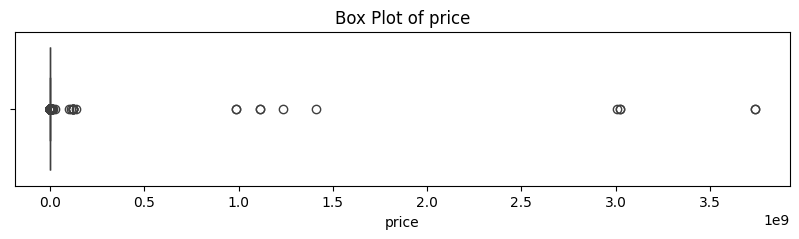

Descriptive Statistics:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Q1 (25th percentile): 5900.0
Q3 (75th percentile): 26485.75
IQR: 20585.75
Lower Bound for Outliers: -24978.625
Upper Bound for Outliers: 57364.375
Number of outliers based on IQR method: 8177
Percentage of outliers: 1.92%

--- Analyzing column: year ---


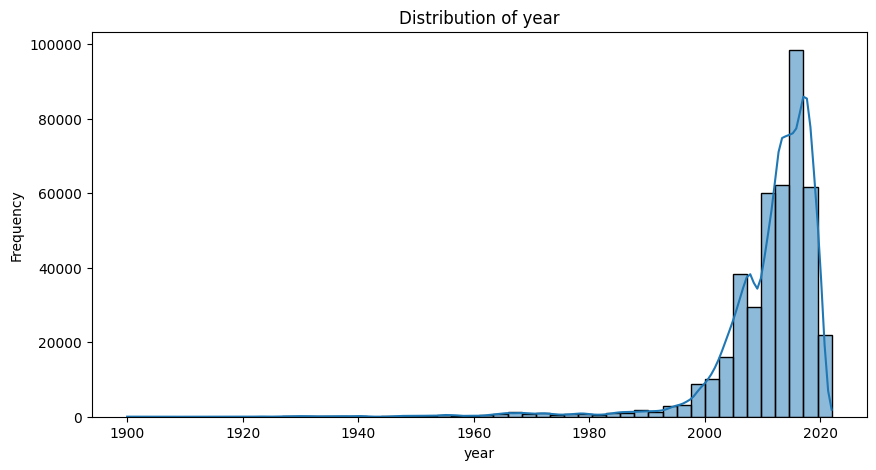

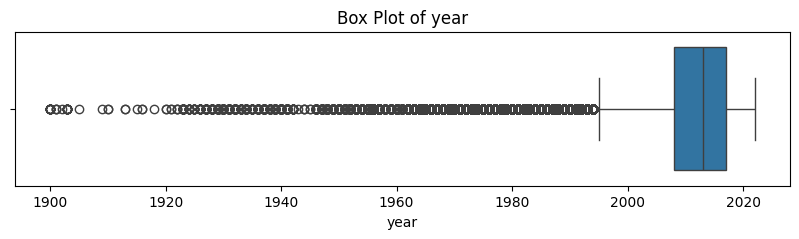

Descriptive Statistics:
count    426880.000000
mean       2011.240173
std           9.439234
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

Q1 (25th percentile): 2008.0
Q3 (75th percentile): 2017.0
IQR: 9.0
Lower Bound for Outliers: 1994.5
Upper Bound for Outliers: 2030.5
Number of outliers based on IQR method: 15896
Percentage of outliers: 3.72%

--- Analyzing column: odometer ---


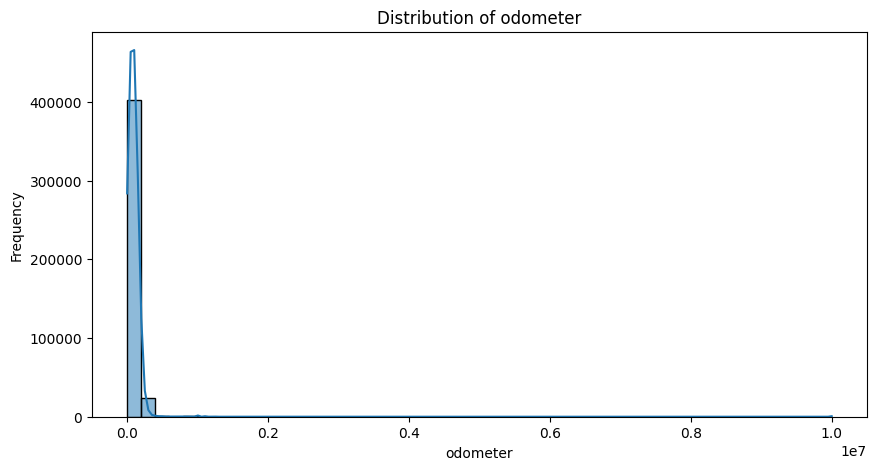

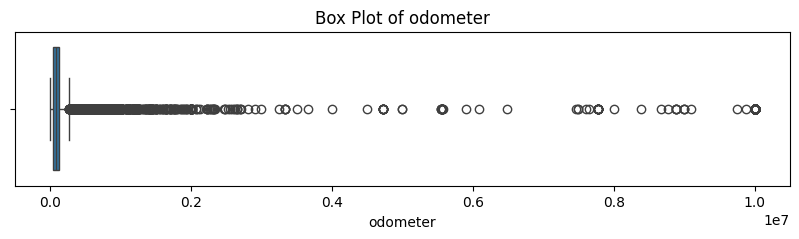

Descriptive Statistics:
count    4.268800e+05
mean     9.791454e+04
std      2.127801e+05
min      0.000000e+00
25%      3.813000e+04
50%      8.554800e+04
75%      1.330000e+05
max      1.000000e+07
Name: odometer, dtype: float64

Q1 (25th percentile): 38130.0
Q3 (75th percentile): 133000.0
IQR: 94870.0
Lower Bound for Outliers: -104175.0
Upper Bound for Outliers: 275305.0
Number of outliers based on IQR method: 4481
Percentage of outliers: 1.05%


In [11]:
numerical_cols = ['price', 'year', 'odometer']

for col in numerical_cols:
    print(f"\n--- Analyzing column: {col} ---")

    # Generate a histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(vehicles_df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Generate a box plot
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=vehicles_df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

    # Calculate descriptive statistics, including quartiles
    stats = vehicles_df[col].describe()
    print("Descriptive Statistics:")
    print(stats)

    # Calculate IQR and bounds
    Q1 = stats['25%']
    Q3 = stats['75%']
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nQ1 (25th percentile): {Q1}")
    print(f"Q3 (75th percentile): {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound for Outliers: {lower_bound}")
    print(f"Upper Bound for Outliers: {upper_bound}")

    outliers_count = vehicles_df[(vehicles_df[col] < lower_bound) | (vehicles_df[col] > upper_bound)].shape[0]
    print(f"Number of outliers based on IQR method: {outliers_count}")
    print(f"Percentage of outliers: {outliers_count / len(vehicles_df) * 100:.2f}%")


### Strategy for Handling Outliers

Based on the visualizations and statistical analysis, here's the proposed strategy for handling outliers in each numerical column:

1.  **`price` column:**
    *   **Observations:** The maximum price is extremely high (3.74e+09), indicating clear outliers. There are also cars with a price of 0, which are erroneous. The percentage of outliers is 1.92%, which is relatively small.
    *   **Strategy:** Cap values that are above the `upper_bound` (57364.375) and values that are below the `lower_bound` (0 is already the minimum, but values below Q1 are also considered outliers) to maintain reasonable price ranges. Specifically, we'll set prices below a reasonable minimum (e.g., $500, considering the minimum is 0) to this minimum, and cap prices above the `upper_bound` determined by the IQR method. Cars with `price = 0` will also be removed.

2.  **`year` column:**
    *   **Observations:** The minimum year is 1900 and the maximum year is 2022. While cars from 1900 are old, they might still exist. The `upper_bound` for outliers is 2030.5, which includes future years and suggests data entry errors or future models. The `lower_bound` for outliers is 1994.5. The percentage of outliers is 3.72%.
    *   **Strategy:** Cap years above a reasonable maximum (e.g., the current year or dataset's max) and years below a reasonable minimum (e.g., 1950, as cars older than that might be collector's items and not representative of typical used cars). We will cap years above the `upper_bound` (2030.5) to the `upper_bound` and years below the `lower_bound` (1994.5) to the `lower_bound`. Cars with year 2022 are not outliers given current context.

3.  **`odometer` column:**
    *   **Observations:** The maximum odometer reading is extremely high (1.00e+07), indicating clear outliers. The minimum odometer is 0, which could be for new cars or errors. The percentage of outliers is 1.05%.
    *   **Strategy:** Cap values that are above the `upper_bound` (275305.0) and values that are below the `lower_bound` (0 is not an outlier here, but potentially very low values could be). We will cap values above the `upper_bound` to the `upper_bound`. For values at 0, we will assume they represent very low mileage or new cars and keep them, as `0` is a valid entry for a brand-new car and values like `-104175.0` are nonsensical as lower bounds for odometer.

In [12]:
print("Addressing Outliers")

# --- Handling 'price' outliers ---
# Removing rows where price is 0 (erroneous entries)
vehicles_df = vehicles_df[vehicles_df['price'] != 0].copy()
print(f"Removed rows with price = 0. New shape: {vehicles_df.shape}")

# Recalculating IQR bounds for price after removing 0s, as they might shift the quartiles
price_stats = vehicles_df['price'].describe()
price_Q1 = price_stats['25%']
price_Q3 = price_stats['75%']
price_IQR = price_Q3 - price_Q1
price_lower_bound = max(500, price_Q1 - 1.5 * price_IQR) # Set a practical minimum of 500 USD
price_upper_bound = price_Q3 + 1.5 * price_IQR

vehicles_df['price'] = np.where(vehicles_df['price'] < price_lower_bound, price_lower_bound, vehicles_df['price'])
vehicles_df['price'] = np.where(vehicles_df['price'] > price_upper_bound, price_upper_bound, vehicles_df['price'])
print(f"Capped 'price' column. Lower bound: {price_lower_bound}, Upper bound: {price_upper_bound}")

# --- Handling 'year' outliers ---
year_stats = vehicles_df['year'].describe()
year_Q1 = year_stats['25%']
year_Q3 = year_stats['75%']
year_IQR = year_Q3 - year_Q1
year_lower_bound = max(1950, year_Q1 - 1.5 * year_IQR) # Cap at 1950 as a reasonable minimum
year_upper_bound = min(2023, year_Q3 + 1.5 * year_IQR) # Cap at current year or slightly above

vehicles_df['year'] = np.where(vehicles_df['year'] < year_lower_bound, year_lower_bound, vehicles_df['year'])
vehicles_df['year'] = np.where(vehicles_df['year'] > year_upper_bound, year_upper_bound, vehicles_df['year'])
print(f"Capped 'year' column. Lower bound: {year_lower_bound}, Upper bound: {year_upper_bound}")

# --- Handling 'odometer' outliers ---
odometer_stats = vehicles_df['odometer'].describe()
odometer_Q1 = odometer_stats['25%']
odometer_Q3 = odometer_stats['75%']
odometer_IQR = odometer_Q3 - odometer_Q1
odometer_upper_bound = odometer_Q3 + 1.5 * odometer_IQR

# Only cap upper bound as 0 is a valid odometer reading and values below it are handled by current logic
vehicles_df['odometer'] = np.where(vehicles_df['odometer'] > odometer_upper_bound, odometer_upper_bound, vehicles_df['odometer'])
print(f"Capped 'odometer' column. Upper bound: {odometer_upper_bound}")

print("Outlier handling complete. Displaying descriptive statistics for affected columns:")
print(vehicles_df[['price', 'year', 'odometer']].describe())

Addressing Outliers
Removed rows with price = 0. New shape: (393985, 16)
Capped 'price' column. Lower bound: 500, Upper bound: 58475.0
Capped 'year' column. Lower bound: 1994.5, Upper bound: 2023
Capped 'odometer' column. Upper bound: 280120.5
Outlier handling complete. Displaying descriptive statistics for affected columns:
               price           year       odometer
count  393985.000000  393985.000000  393985.000000
mean    18588.201505    2011.775485   92562.199549
std     13890.734279       6.447914   63385.016491
min       500.000000    1994.500000       0.000000
25%      7000.000000    2008.000000   38253.000000
50%     15000.000000    2013.000000   86408.000000
75%     27590.000000    2017.000000  135000.000000
max     58475.000000    2022.000000  280120.500000


## Standardizing Categorical Features

Clean and standardize categorical columns by checking for inconsistencies (e.g., variations in spelling, mixed cases), consolidating similar categories, and handling rare categories.

In [13]:
print("Identifying categorical columns and inspecting unique values and their counts...")

categorical_cols = vehicles_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(vehicles_df[col].value_counts())

Identifying categorical columns and inspecting unique values and their counts...

--- Column: region ---
region
columbus                  3392
jacksonville              3177
omaha / council bluffs    2967
new hampshire             2944
grand rapids              2934
                          ... 
meridian                    22
southwest MS                13
kansas city                 10
fort smith, AR               8
west virginia (old)          8
Name: count, Length: 404, dtype: int64

--- Column: manufacturer ---
manufacturer
ford               81040
chevrolet          50643
toyota             31600
honda              19867
jeep               17461
nissan             17395
ram                16464
gmc                15431
bmw                13745
dodge              12369
mercedes-benz      10462
hyundai             9374
subaru              8986
volkswagen          8898
lexus               7741
kia                 7547
audi                7180
cadillac            6591
acura          

**Adding age of the car as a feature**:
To create the `car_age` feature and inspect it, using `datetime.now().year` for current year, then subtract the car's 'year' from it to create the new column. Finally, print the descriptive statistics and plot a histogram to visualize its distribution.

Creating 'car_age' feature...
Current year: 2025
Successfully created 'car_age' column.

Descriptive statistics for 'car_age':
count    393985.000000
mean         13.224515
std           6.447914
min           3.000000
25%           8.000000
50%          12.000000
75%          17.000000
max          30.500000
Name: car_age, dtype: float64


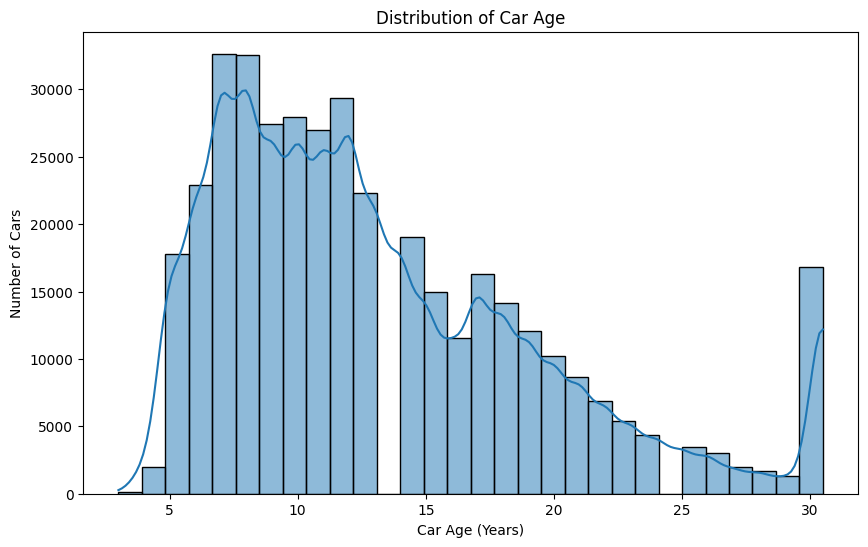

First 5 rows with 'car_age' column:
           id                  region    price    year manufacturer  model  \
0  7222695916                prescott   6000.0  2013.0         ford  f-150   
1  7218891961            fayetteville  11900.0  2013.0         ford  f-150   
2  7221797935            florida keys  21000.0  2013.0         ford  f-150   
3  7222270760  worcester / central MA   1500.0  2013.0         ford  f-150   
4  7210384030              greensboro   4900.0  2013.0         ford  f-150   

  condition cylinders fuel  odometer title_status transmission    drive  \
0   unknown   unknown  gas   85548.0        clean    automatic  unknown   
1   unknown   unknown  gas   85548.0        clean    automatic  unknown   
2   unknown   unknown  gas   85548.0        clean    automatic  unknown   
3   unknown   unknown  gas   85548.0        clean    automatic  unknown   
4   unknown   unknown  gas   85548.0        clean    automatic  unknown   

      type paint_color state  car_age  
0  u

In [14]:
from datetime import datetime

print("Creating 'car_age' feature...")

# 1. Get the current year
current_year = datetime.now().year
print(f"Current year: {current_year}")

# 2. Create a new column named `car_age`
vehicles_df['car_age'] = current_year - vehicles_df['year']

print("Successfully created 'car_age' column.")

# 3. Display the descriptive statistics for the new `car_age` column
print("\nDescriptive statistics for 'car_age':")
print(vehicles_df['car_age'].describe())

# 4. Create a histogram of the `car_age` column
plt.figure(figsize=(10, 6))
sns.histplot(vehicles_df['car_age'], kde=True, bins=30)
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Number of Cars')
plt.show()

print("First 5 rows with 'car_age' column:")
print(vehicles_df.head())

In [15]:
vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393985 entries, 0 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            393985 non-null  int64  
 1   region        393985 non-null  object 
 2   price         393985 non-null  float64
 3   year          393985 non-null  float64
 4   manufacturer  393985 non-null  object 
 5   model         393985 non-null  object 
 6   condition     393985 non-null  object 
 7   cylinders     393985 non-null  object 
 8   fuel          393985 non-null  object 
 9   odometer      393985 non-null  float64
 10  title_status  393985 non-null  object 
 11  transmission  393985 non-null  object 
 12  drive         393985 non-null  object 
 13  type          393985 non-null  object 
 14  paint_color   393985 non-null  object 
 15  state         393985 non-null  object 
 16  car_age       393985 non-null  float64
dtypes: float64(4), int64(1), object(12)
memory usage: 54.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

*****Analysis*****:
Excluding high cardinality categorical columns such as model, manufacturer as it makes the model really complex. Restricting it to the following categorical columns.
* Condition
* Fuel
* Drive

In [16]:
categorical_features = ['condition', 'fuel','drive','cylinders']
numeric_features = ['year', 'odometer','car_age']

X = vehicles_df[numeric_features + categorical_features]
y = vehicles_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}")

Train set: 275789 | Test set: 118196


#### Defining Pre-Processing Pipeline

In [19]:
print("\n" + "=" * 80)
print("BUILDING PREPROCESSING PIPELINE")
print("=" * 80)

# Preprocessing transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("\nPreprocessing steps:")
print("  ✓ Numeric: StandardScaler")
print("  ✓ Categorical: OneHotEncoder")


BUILDING PREPROCESSING PIPELINE

Preprocessing steps:
  ✓ Numeric: StandardScaler
  ✓ Categorical: OneHotEncoder


In [17]:
# Pre-Processing Pipeline for Polynomial Features
print("\n" + "=" * 80)
print("BUILDING PREPROCESSING PIPELINE FOR POLYNOMIAL FEATURES")
print("=" * 80)

# Preprocessing transformations
preprocessor_Poly = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("\nPreprocessing steps:")
print("  ✓ Numeric: StandardScaler → PolynomialFeatures (degree=2)")
print("  ✓ Categorical: OneHotEncoder")


BUILDING PREPROCESSING PIPELINE FOR POLYNOMIAL FEATURES

Preprocessing steps:
  ✓ Numeric: StandardScaler → PolynomialFeatures (degree=2)
  ✓ Categorical: OneHotEncoder


#### Sequential Feature Selection

In [20]:
print("\n" + "=" * 80)
print("APPLYING SEQUENTIAL FEATURE SELECTION")
print("=" * 80)


# Fit preprocessor to get transformed features
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nFeatures before SFS: {X_train_transformed.shape[1]}")

n_features_to_select = 10
print(f"Selecting {n_features_to_select} features using Sequential Feature Selection...")

# Apply SFS with Linear Regression as estimator
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=n_features_to_select, cv=5, n_jobs=-1)
sfs.fit(X_train_transformed, y_train)

# Get selected feature mask
selected_mask = sfs.get_support()
X_train_sfs = sfs.transform(X_train_transformed)
X_test_sfs = sfs.transform(X_test_transformed)

print(f"Features after SFS: {X_train_sfs.shape[1]}")
print(f"\nSequential Feature Selection complete!")


APPLYING SEQUENTIAL FEATURE SELECTION

Features before SFS: 28
Selecting 10 features using Sequential Feature Selection...
Features after SFS: 10

Sequential Feature Selection complete!


#### Get Feature Names for Selected Features

In [21]:
all_feature_names = preprocessor.get_feature_names_out()

# Get selected feature names
selected_mask = sfs.get_support()
selected_feature_names = all_feature_names[selected_mask]

print("\n" + "=" * 80)
print("SELECTED FEATURES FROM SEQUENTIAL FEATURE SELECTION")
print("=" * 80)
print(f"\nTotal Selected Features: {len(selected_feature_names)}\n")

for idx, feature_name in enumerate(selected_feature_names, 1):
    print(f"{idx:2d}. {feature_name}")


SELECTED FEATURES FROM SEQUENTIAL FEATURE SELECTION

Total Selected Features: 10

 1. num__odometer
 2. num__car_age
 3. cat__condition_excellent
 4. cat__fuel_diesel
 5. cat__fuel_other
 6. cat__drive_4wd
 7. cat__drive_fwd
 8. cat__drive_unknown
 9. cat__cylinders_4 cylinders
10. cat__cylinders_8 cylinders


#### Linear Regression on Sequential Features

In [22]:
print("\n1. Linear Regression (on SFS-selected features)")
lr_pipeline = Pipeline([
    ('regressor', LinearRegression())
])

lr_params = {}
lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)
lr_grid.fit(X_train_sfs, y_train)
y_pred_lr = lr_grid.predict(X_test_sfs)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"   MSE:  {mse_lr:,.2f}")
print(f"   RMSE: {rmse_lr:,.2f}")
print(f"   R²:   {r2_lr:.4f}")


1. Linear Regression (on SFS-selected features)
   MSE:  84,956,529.30
   RMSE: 9,217.19
   R²:   0.5586


#### Ridge Regression on Original Features

In [23]:
# ---- RIDGE REGRESSION ON ORIGINAL FEATURES ----
print("\n2. Ridge Regression (on original full features)")
ridge_pipeline = Pipeline([
    ('regressor', Ridge())
])

ridge_params = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)
ridge_grid.fit(X_train_transformed, y_train)
y_pred_ridge = ridge_grid.predict(X_test_transformed)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"   Best Alpha: {ridge_grid.best_params_['regressor__alpha']}")
print(f"   MSE:  {mse_ridge:,.2f}")
print(f"   RMSE: {rmse_ridge:,.2f}")
print(f"   R²:   {r2_ridge:.4f}")


2. Ridge Regression (on original full features)
   Best Alpha: 1
   MSE:  84,465,908.86
   RMSE: 9,190.53
   R²:   0.5611


#### Lasso Regression on Original Features

In [24]:
# ---- LASSO REGRESSION ON ORIGINAL FEATURES ----
print("\n3. Lasso Regression (on original full features)")
lasso_pipeline = Pipeline([
    ('regressor', Lasso(max_iter=10000))
])

lasso_params = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)
lasso_grid.fit(X_train_transformed, y_train)
y_pred_lasso = lasso_grid.predict(X_test_transformed)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"   Best Alpha: {lasso_grid.best_params_['regressor__alpha']}")
print(f"   MSE:  {mse_lasso:,.2f}")
print(f"   RMSE: {rmse_lasso:,.2f}")
print(f"   R²:   {r2_lasso:.4f}")


3. Lasso Regression (on original full features)
   Best Alpha: 0.01
   MSE:  84,465,788.22
   RMSE: 9,190.53
   R²:   0.5611


#### Sequential Feature Selection with Polynomial Features

In [28]:
X_poly = vehicles_df[numeric_features + categorical_features]
y_poly = vehicles_df['price']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.30, random_state=42)

print(f"Train set: {X_train_p.shape[0]} | Test set: {X_test_p.shape[0]}")

Train set: 275789 | Test set: 118196


In [29]:
print("\n" + "=" * 80)
print("APPLYING SEQUENTIAL FEATURE SELECTION WITH POLYNOMIAL FEATURES")
print("=" * 80)


# Fit preprocessor to get transformed features
X_train_transformed_p = preprocessor_Poly.fit_transform(X_train_p)
X_test_transformed_p = preprocessor_Poly.transform(X_test_p)

print(f"\nFeatures before SFS: {X_train_transformed_p.shape[1]}")

n_features_to_select = 10
print(f"Selecting {n_features_to_select} features using Sequential Feature Selection...")

# Apply SFS with Linear Regression as estimator
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=n_features_to_select, cv=5, n_jobs=-1)
sfs.fit(X_train_transformed_p, y_train_p)

# Get selected feature mask
selected_mask_p = sfs.get_support()
X_train_sfs_p = sfs.transform(X_train_transformed_p)
X_test_sfs_p = sfs.transform(X_test_transformed_p)

print(f"Features after SFS: {X_train_sfs_p.shape[1]}")
print(f"\nSequential Feature Selection with Polynomial features complete!")


APPLYING SEQUENTIAL FEATURE SELECTION WITH POLYNOMIAL FEATURES

Features before SFS: 34
Selecting 10 features using Sequential Feature Selection...
Features after SFS: 10

Sequential Feature Selection with Polynomial features complete!


#### Get Feature Names for Selected Features with Polynomial

In [30]:
feature_names_numeric_p = preprocessor_Poly.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numeric_features)
feature_names_categorical_p = preprocessor_Poly.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names_p = np.concatenate([feature_names_numeric_p, feature_names_categorical_p])

# Get selected feature names
selected_feature_names_p = all_feature_names_p[selected_mask_p]

print("\n" + "=" * 80)
print("SELECTED FEATURES FROM SEQUENTIAL POLYNOMIAL FEATURE SELECTION")
print("=" * 80)
print(f"\nTotal Selected Features: {len(selected_feature_names_p)}\n")

for idx, feature_name in enumerate(selected_feature_names_p, 1):
    print(f"{idx:2d}. {feature_name}")


SELECTED FEATURES FROM SEQUENTIAL POLYNOMIAL FEATURE SELECTION

Total Selected Features: 10

 1. odometer
 2. car_age
 3. year^2
 4. odometer^2
 5. fuel_diesel
 6. fuel_other
 7. drive_fwd
 8. drive_unknown
 9. cylinders_4 cylinders
10. cylinders_8 cylinders


#### Linear regression on Sequential Polynomial Features

In [34]:
print("\n4. Linear Regression (on SFS-selected Polynomial features)")
lr_pipeline_p = Pipeline([
    ('regressor', LinearRegression())
])

lr_params_p = {}
lr_grid_p = GridSearchCV(lr_pipeline_p, lr_params_p, cv=5, scoring='r2', n_jobs=-1, verbose=0)
lr_grid_p.fit(X_train_sfs_p, y_train_p)
y_pred_lr_p = lr_grid_p.predict(X_test_sfs_p)
mse_lr_p = mean_squared_error(y_test_p, y_pred_lr_p)
rmse_lr_p = np.sqrt(mse_lr_p)
r2_lr_p = r2_score(y_test, y_pred_lr_p)
print(f"   MSE:  {mse_lr_p:,.2f}")
print(f"   RMSE: {rmse_lr_p:,.2f}")
print(f"   R²:   {r2_lr_p:.4f}")


4. Linear Regression (on SFS-selected Polynomial features)
   MSE:  78,845,120.19
   RMSE: 8,879.48
   R²:   0.5903


#### Ridge Regression on Original Features (With Polynomial features)

In [35]:
# ---- RIDGE REGRESSION ON ORIGINAL FEATURES (POLYNOMIAL) ----
print("\n5. Ridge Regression (on original full features with Polynomial)")
ridge_pipeline = Pipeline([
    ('regressor', Ridge())
])

ridge_params_p = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}
ridge_grid_p = GridSearchCV(ridge_pipeline, ridge_params_p, cv=5, scoring='r2', n_jobs=-1, verbose=0)
ridge_grid_p.fit(X_train_transformed_p, y_train_p)
y_pred_ridge_p = ridge_grid_p.predict(X_test_transformed_p)
mse_ridge_p = mean_squared_error(y_test_p, y_pred_ridge_p)
rmse_ridge_p = np.sqrt(mse_ridge_p)
r2_ridge_p = r2_score(y_test_p, y_pred_ridge_p)
print(f"   Best Alpha: {ridge_grid_p.best_params_['regressor__alpha']}")
print(f"   MSE:  {mse_ridge_p:,.2f}")
print(f"   RMSE: {rmse_ridge_p:,.2f}")
print(f"   R²:   {r2_ridge_p:.4f}")


5. Ridge Regression (on original full features with Polynomial)
   Best Alpha: 1
   MSE:  77,566,204.70
   RMSE: 8,807.17
   R²:   0.5970


#### Lasso Regression on Original Features (with Polynomial Features)

In [37]:
# ---- LASSO REGRESSION ON ORIGINAL FEATURES (POLYNOMIAL) ----
print("\n6. Lasso Regression (on original full Polynomial features)")
lasso_pipeline = Pipeline([
    ('regressor', Lasso(max_iter=10000))
])

lasso_params_p = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}
lasso_grid_p = GridSearchCV(lasso_pipeline, lasso_params_p, cv=5, scoring='r2', n_jobs=-1, verbose=0)
lasso_grid_p.fit(X_train_transformed_p, y_train_p)
y_pred_lasso_p = lasso_grid_p.predict(X_test_transformed_p)
mse_lasso_p = mean_squared_error(y_test_p, y_pred_lasso_p)
rmse_lasso_p = np.sqrt(mse_lasso_p)
r2_lasso_p = r2_score(y_test_p, y_pred_lasso_p)
print(f"   Best Alpha: {lasso_grid_p.best_params_['regressor__alpha']}")
print(f"   MSE:  {mse_lasso_p:,.2f}")
print(f"   RMSE: {rmse_lasso_p:,.2f}")
print(f"   R²:   {r2_lasso_p:.4f}")


6. Lasso Regression (on original full Polynomial features)
   Best Alpha: 0.01
   MSE:  77,566,064.48
   RMSE: 8,807.16
   R²:   0.5970


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Model Performance Summary

In [38]:
print("\n" + "*" * 80)
print("PERFORMANCE SUMMARY")
print("*" * 80)

results_df = pd.DataFrame({
    'Model': ['Linear Regression (SFS Features)', 'Ridge (Original Features)', 'Lasso (Original Features)','Linear Regression (SFS Poly Features)', 'Ridge (Original Poly Features)', 'Lasso (Original Poly Features)'],
    'MSE': [mse_lr, mse_ridge, mse_lasso,mse_lr_p, mse_ridge_p, mse_lasso_p],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_lr_p, rmse_ridge_p, rmse_lasso_p],
    'R² Score': [r2_lr, r2_ridge, r2_lasso, r2_lr_p, r2_ridge_p, r2_lasso_p],
    'Features Used': [n_features_to_select, X_train_transformed.shape[1], X_train_transformed.shape[1], n_features_to_select,X_train_transformed_p.shape[1],X_train_transformed_p.shape[1]]
})

print("\n" + results_df.to_string(index=False))

best_idx = results_df['R² Score'].idxmax()
best_model = results_df.loc[best_idx, 'Model'].split('\n')[0]
best_r2 = results_df.loc[best_idx, 'R² Score']

print(f"\n✓ Best Model: {best_model} (R² = {best_r2:.4f})")


********************************************************************************
PERFORMANCE SUMMARY
********************************************************************************

                                Model          MSE        RMSE  R² Score  Features Used
     Linear Regression (SFS Features) 8.495653e+07 9217.186626  0.558581             10
            Ridge (Original Features) 8.446591e+07 9190.533655  0.561131             28
            Lasso (Original Features) 8.446579e+07 9190.527091  0.561131             28
Linear Regression (SFS Poly Features) 7.884512e+07 8879.477473  0.590335             10
       Ridge (Original Poly Features) 7.756620e+07 8807.167803  0.596980             34
       Lasso (Original Poly Features) 7.756606e+07 8807.159842  0.596981             34

✓ Best Model: Lasso (Original Poly Features) (R² = 0.5970)



✓ Visualization saved: model_comparison.png


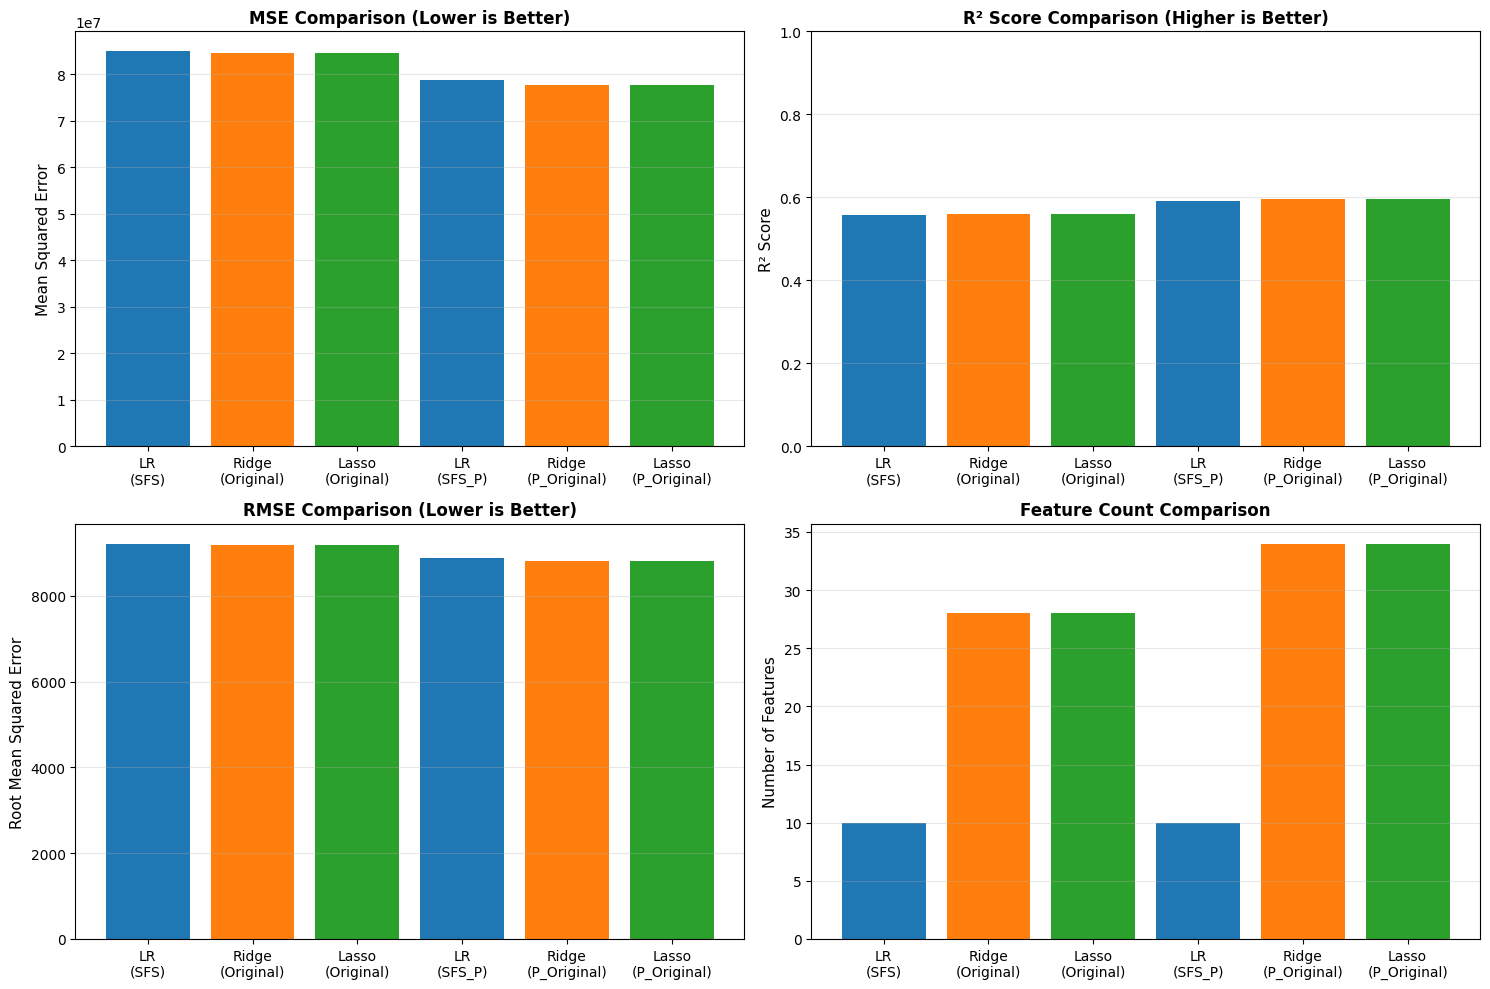

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MSE Comparison
model_labels = ['LR\n(SFS)', 'Ridge\n(Original)', 'Lasso\n(Original)','LR\n(SFS_P)', 'Ridge\n(P_Original)', 'Lasso\n(P_Original)']
axes[0, 0].bar(model_labels, results_df['MSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('Mean Squared Error', fontsize=11)
axes[0, 0].set_title('MSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# R² Comparison
axes[0, 1].bar(model_labels, results_df['R² Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('R² Score', fontsize=11)
axes[0, 1].set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# RMSE Comparison
axes[1, 0].bar(model_labels, results_df['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('Root Mean Squared Error', fontsize=11)
axes[1, 0].set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Features Used
axes[1, 1].bar(model_labels, results_df['Features Used'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_ylabel('Number of Features', fontsize=11)
axes[1, 1].set_title('Feature Count Comparison', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: model_comparison.png")

****Summary:****
The models achieved an R² score ranging from 0.55 to 0.59, indicating that about 56% - 59% of the variance in used car prices can be explained by the selected features and models. The Root Mean Squared Error (RMSE) ranged from around $8,807 to $9,217, meaning the models' predictions were, on average, off by this amount.



****Best Model:**** The Lasso Regression model trained on the full set of original features with Polynomial Features (Lasso (Original Poly Features)) emerged as the best performer, achieving an R² of 0.5970 and an RMSE of $8,807.16. The Ridge Regression with polynomial features performed almost identically.

****Impact of Polynomial Features:**** Though inclusion of polynomial features improved model performance (R² increased from ~0.56 to ~0.59), indicating non-linear relationships between the numerical features and car price, the use of polynomial features introduces complex, non-interpretable interaction terms (eg., year^2) which complicate business communication.

****Impact of Regularization:**** For both the standard and polynomial feature sets, Ridge and Lasso regression slightly outperformed simple Linear Regression, suggesting that regularization was beneficial in handling potential multicollinearity and preventing overfitting, though the impact is not very significant.


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

****Actionable Insights:****
Key drivers of car price include odometer reading, car age, and their non-linear transformations (year^2, odometer^2), alongside specific car attributes like fuel type (diesel is positive), drive type (fwd, unknown), and number of cylinders (4 and 8 cylinders being distinct indicators). Dealerships should leverage these insights for more accurate pricing, inventory valuation, and targeted marketing.


****Further Improvement:**** An R² of 0.56 - 0.59 is a reasonable starting point, but there's room for improvement. Future work could include:
Incorporating High-Cardinality Features: Experimenting with manufacturer and model (perhaps using more advanced encoding techniques like target encoding or embedding) could significantly boost model performance, as these are highly influential features in car pricing.
Regional Pricing Effects: The region column might have significant pricing variations that could be explored.
****
Overall, the analysis provides a solid foundation for understanding used car price drivers, with the Lasso and Ridge models offering the best predictive capability among the tested linear models.